In [66]:
from matplotlib import pyplot as plt

from pathlib import Path
import json

import numpy as np 

import matplotlib as mpt

In [8]:
ARTIFACT_DIR = Path("../../artifacts/2023-05-S5/experiment-binary-task")

In [50]:
def load_stats(dataset, model, layer, basis_name, num_training_samples=None):
    
    if num_training_samples is not None:
        dataset = f"{dataset}--n{num_training_samples}"
    
    
    filepath = ARTIFACT_DIR / dataset / model / layer / basis_name / "stats.json"
    
    
    with open(filepath, "r") as fh:
        stats = json.load(fh)

        aurocs = np.array(stats["arr_auroc"])
        
        original_auroc = stats["original_auroc"]
        
        stats["original_auroc_corrected"] = np.max([original_auroc, 1-original_auroc])
        
        stats["arr_auroc_corrected"] = np.where(aurocs < 0.5, 1-aurocs, aurocs)
        
    
    stats["arr_ks"] = np.array(stats["arr_ks"])
        
    return stats
    
        
load_stats(
    "cifar100-35vs98", "cifar100-resnet18-p1", "layer3", "pca--centered",
    num_training_samples=10
)

{'arr_auroc': [0.47999998927116394,
  0.390500009059906,
  0.3535999655723572,
  0.3547999858856201,
  0.32269999384880066,
  0.3246999979019165,
  0.2964000105857849,
  0.2971000075340271,
  0.30479997396469116,
  0.2928999960422516,
  0.27810001373291016,
  0.26350000500679016,
  0.26520001888275146,
  0.2590000033378601,
  0.2524999976158142,
  0.24650000035762787,
  0.24559998512268066,
  0.23519998788833618,
  0.23000001907348633,
  0.22360000014305115,
  0.21550002694129944,
  0.2160000056028366,
  0.21729998290538788,
  0.21379998326301575,
  0.2126999944448471,
  0.21490000188350677,
  0.2144000083208084,
  0.21570000052452087,
  0.210099995136261,
  0.21279999613761902,
  0.20749999582767487,
  0.2078000009059906,
  0.20409999787807465,
  0.2051999866962433,
  0.2070000022649765,
  0.2084999829530716,
  0.20430000126361847,
  0.20475000143051147,
  0.20319999754428864,
  0.20230001211166382,
  0.20679998397827148,
  0.20409999787807465,
  0.20339998602867126,
  0.2020000070333

[n=1]: auroc(bias): -0.2732999920845032
[n=5]: auroc(bias): -0.2732999920845032
[n=50]: auroc(bias): -0.27330002188682556
[n=None]: auroc(bias): -0.27330002188682556
[n=1]: auroc(bias): -0.2732999920845032
[n=5]: auroc(bias): -0.2732999920845032
[n=50]: auroc(bias): -0.27330002188682556
[n=None]: auroc(bias): -0.27330002188682556
[n=1]: auroc(bias): -0.27330002188682556
[n=5]: auroc(bias): -0.27330002188682556
[n=50]: auroc(bias): -0.27330002188682556
[n=None]: auroc(bias): -0.2732999920845032
[n=1]: auroc(bias): -0.29330000281333923
[n=5]: auroc(bias): -0.27330002188682556
[n=50]: auroc(bias): -0.2732999920845032
[n=None]: auroc(bias): -0.2732999920845032


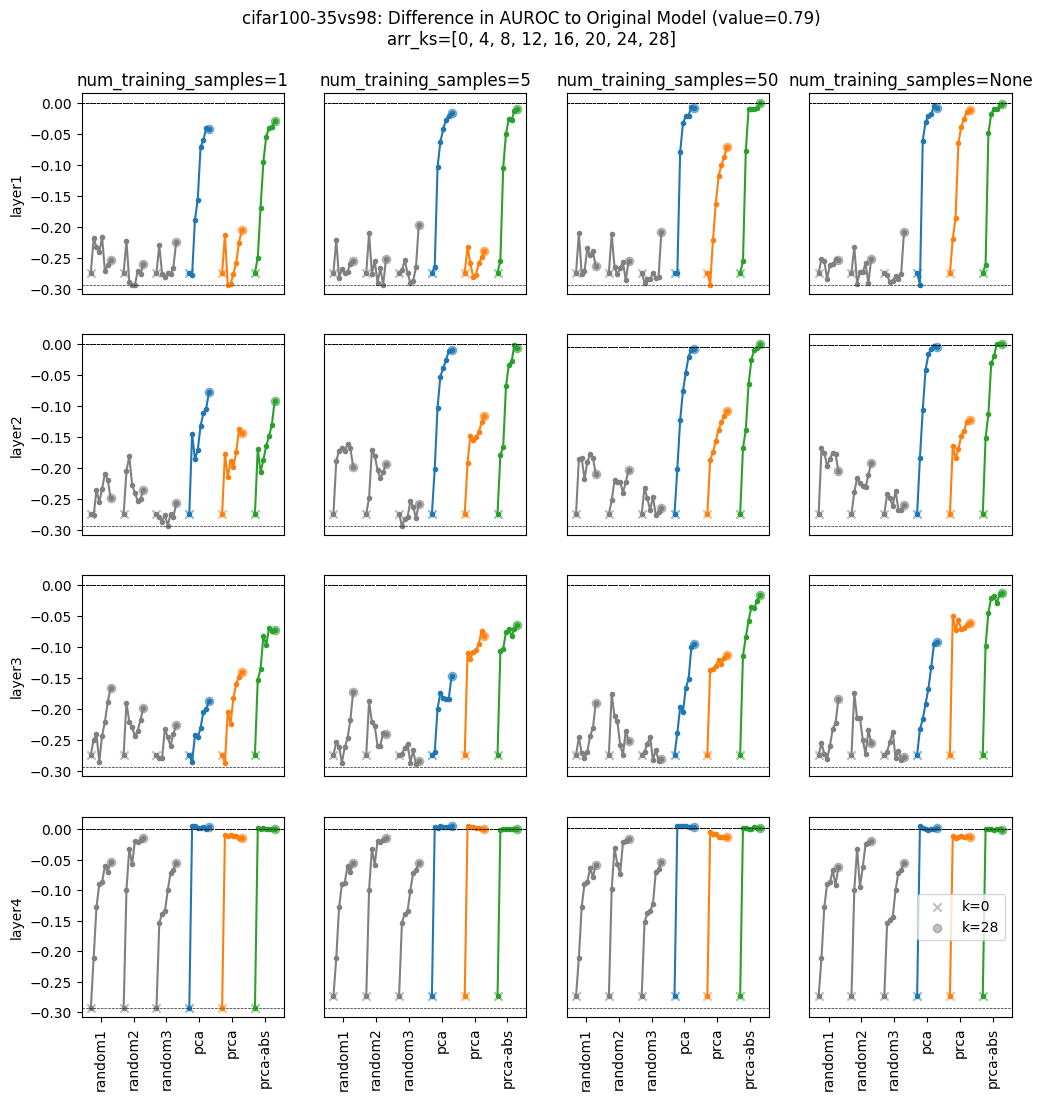

In [190]:
def viz_auroc_at_k(
    model,
    dataset,
    arr_num_samples=[1, 5, 50, None],
    arr_ks=[0, 4, 8, 12, 16, 20, 24, 28],
    layers=["layer1", "layer2", "layer3", "layer4"]
):
    
    
    ncols = len(arr_num_samples)
    nrows = len(layers)
    
    

    plt.figure(figsize=(3*ncols, 3*nrows))
    
    basis_mode = "centered"
    basis_names = [
        "random1",
        "random2",
        "random3",
        "pca",
        "prca",
        "prca-abs",
    ]
    
    
    
    ticks = list(range(len(basis_names)))
    

    
    colors = ["azure", "lightblue", "steelblue", "navy"]
        
    
    
    ref_auroc = load_stats(
        dataset, 
        model,
        layers[0], 
        f"{basis_names[0]}--{basis_mode}",
        num_training_samples=None
    )["original_auroc_corrected"]
    
    plt.suptitle(
        "\n".join(
            [
                f"{dataset}: Difference in AUROC to Original Model (value={ref_auroc:.2f})",
                f"arr_ks={arr_ks}"
            ]
        )
        ,
        y=0.95
    )

    for lix, layer in enumerate(layers):
        

        for nix, num_samples in enumerate(arr_num_samples):
            plt.subplot(nrows, ncols, ncols*lix + nix + 1)

            
            for bix, basis_name in enumerate(basis_names):
                ticks  = np.linspace(bix-0.5 + 0.2, bix+0.5-0.2, len(arr_ks))

                arr_stats = []

                data = load_stats(
                        dataset, 
                        model,
                        layer, 
                        f"{basis_name}--{basis_mode}",
                        num_training_samples=num_samples
                )

                for kix, k in enumerate(arr_ks):
                    stat = float(data["arr_auroc_corrected"][data["arr_ks"] == k])

                    arr_stats.append(stat - ref_auroc)
                
                
                if bix == 0:
                    print(f"[n={num_samples}]: auroc(bias):", arr_stats[0])
                
                
        
                plt.plot(
                    ticks,
                    arr_stats,
                    marker=".",
                    color="gray" if "random" in basis_name else None,
                ) 
            
            
                color = plt.gca().lines[-1].get_color()
            

                plt.scatter(
                    [ticks[0]], [arr_stats[0]], marker="x", color=color,
                    label=f"k={arr_ks[0]}" if "random1" == basis_name else None,
                    alpha=0.5
                )

                plt.scatter(
                    [ticks[-1]], [arr_stats[-1]], marker="o", color=color,
                    label=f"k={arr_ks[-1]}" if "random1" == basis_name else None,
                    alpha=0.5
                )
            
            
                assert ref_auroc == data["original_auroc_corrected"]
            
                plt.axhline(0, ls="--", lw=0.5, color="k")

                if lix == 0:
                    plt.title(f"num_training_samples={num_samples}")
                    
                if nix == 0:
                    plt.ylabel(f"{layer}")
                else:
                    plt.yticks([])
                
                if lix == len(layers) -1 :
                    plt.xticks(np.arange(len(basis_names)), basis_names, rotation=90)
                    
                    if nix == len(arr_num_samples) - 1:
                        plt.legend()  
                else:
                    plt.xticks([])
                    
                plt.axhline(0.5 - ref_auroc, ls="--", lw=0.5, color="k", alpha=0.2)

                
viz_auroc_at_k("cifar100-resnet18-p1", "cifar100-35vs98")

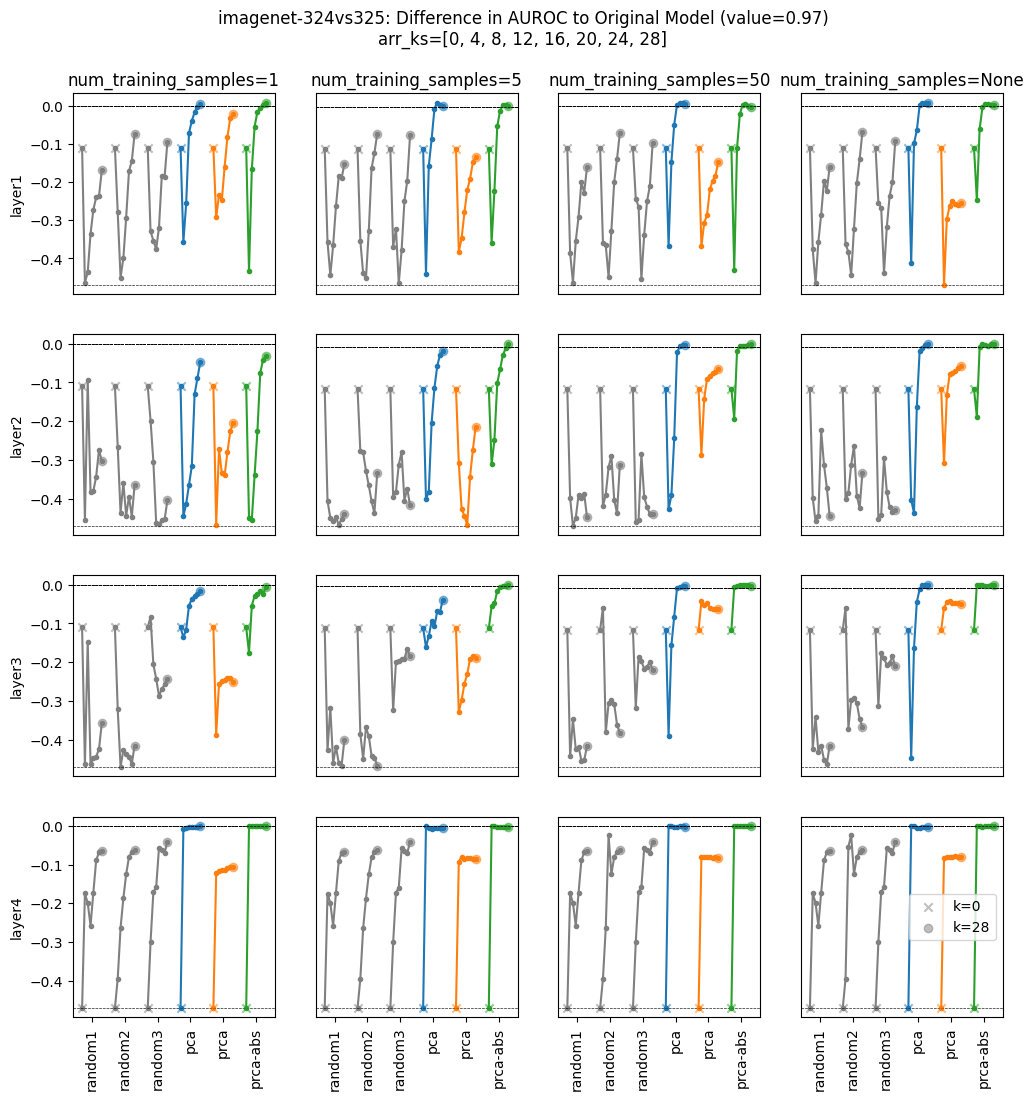

In [186]:
viz_auroc_at_k("imagenet-resnet18-tv", "imagenet-324vs325")

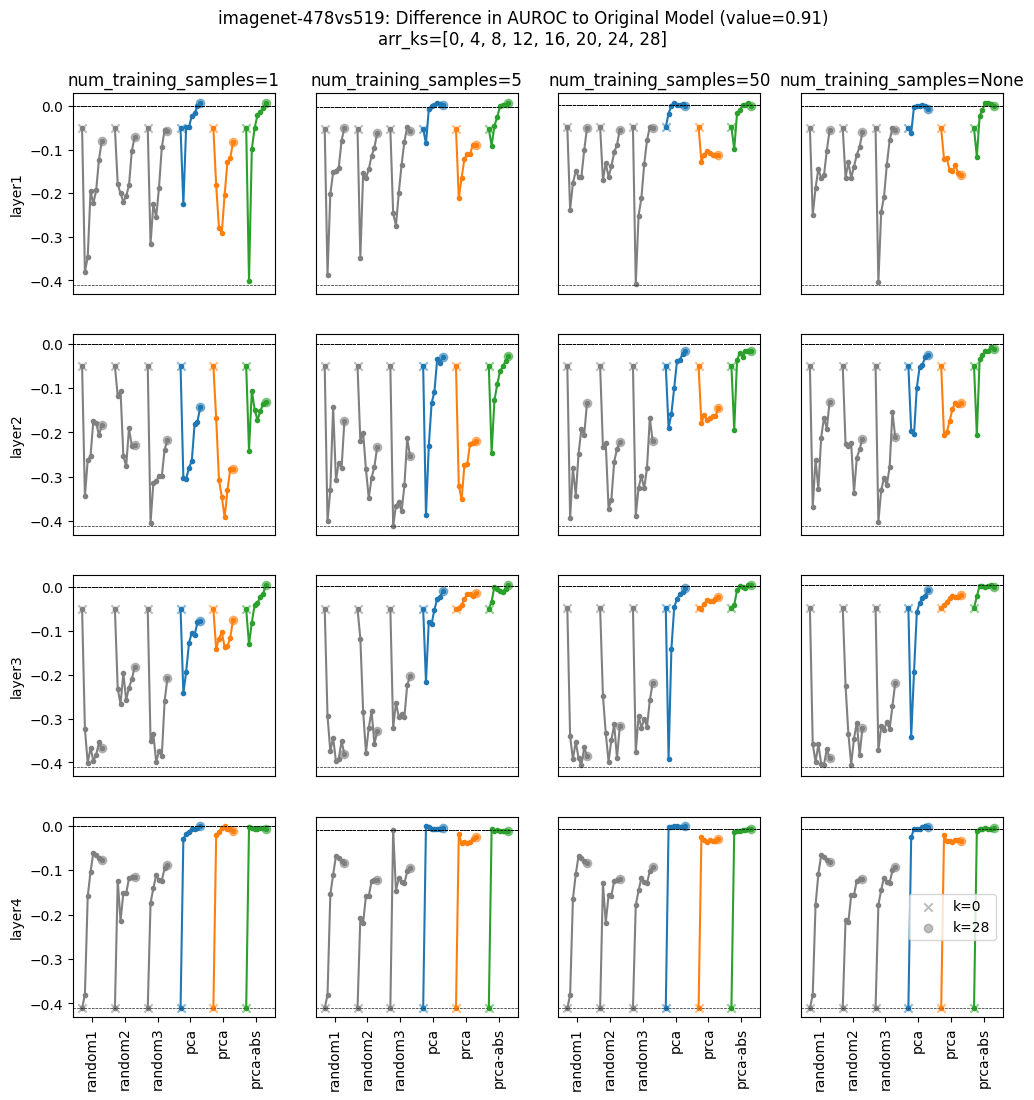

In [187]:
viz_auroc_at_k("imagenet-resnet18-tv", "imagenet-478vs519")

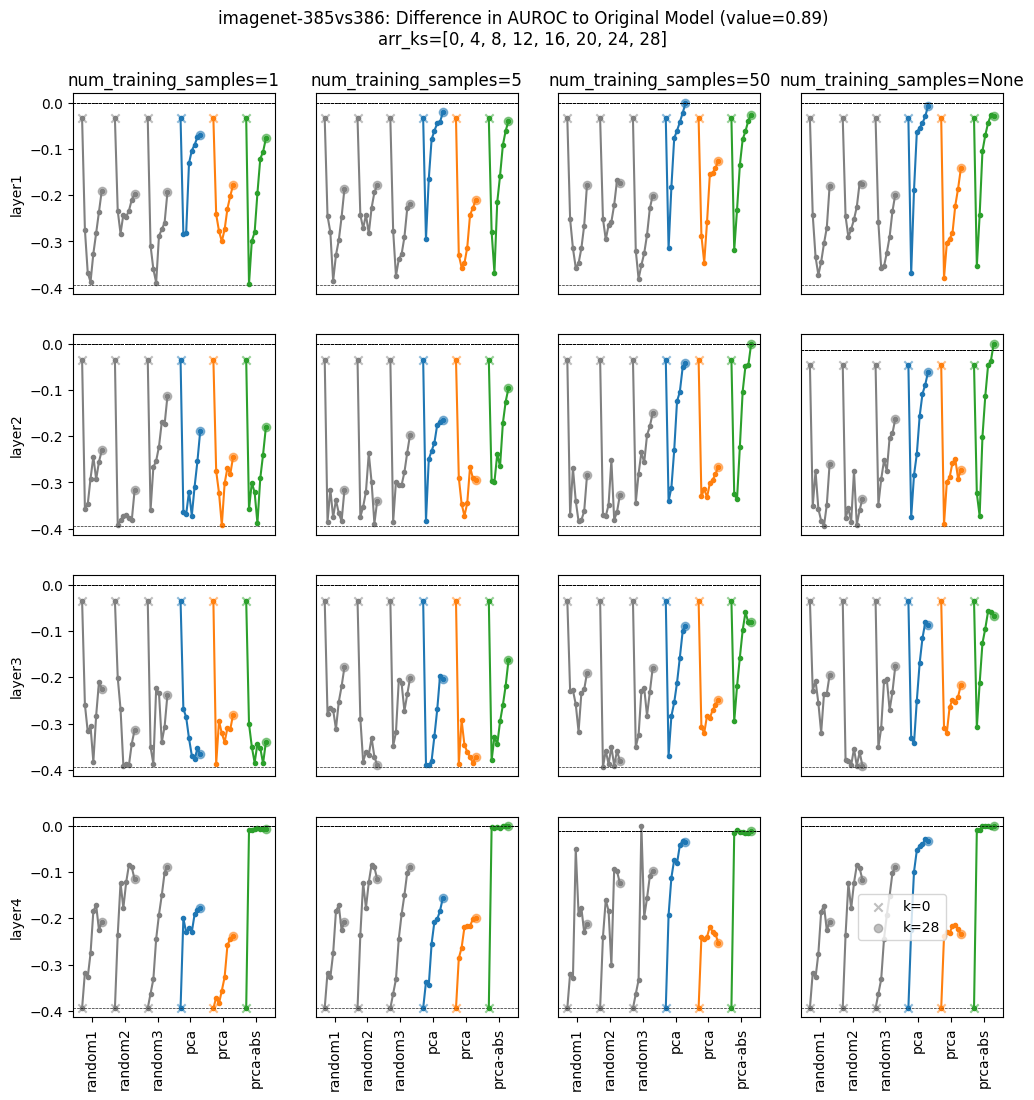

In [189]:
viz_auroc_at_k("imagenet-resnet18-tv", "imagenet-385vs386")